In [4]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install joblib
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")


All libraries imported successfully!


In [6]:
import pandas as pd

In [7]:
df = pd.read_csv(r"C:\Users\Jasmitha\Downloads\ai_cricket_prediction_dataset.csv")
print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)
display(df.head())


Dataset loaded successfully!
Rows and columns: (500, 12)


,team1,team2,venue,toss_winner,toss_decision,team1_recent_wins,team2_recent_wins,team1_rating,team2_rating,team1_avg_score,team2_avg_score,winner
0,Australia,Pakistan,Hyderabad,Pakistan,Bat,9,5,80,93,202,185,Australia
1,Bangladesh,England,Kolkata,England,Field,7,6,94,86,176,208,England
2,India,Bangladesh,Ahmedabad,India,Field,5,6,92,89,206,152,India
3,South Africa,England,Chennai,South Africa,Field,7,4,89,97,196,209,South Africa
4,Pakistan,Bangladesh,Chennai,Bangladesh,Field,4,8,75,91,191,153,Bangladesh


In [8]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
['team1', 'team2', 'venue', 'toss_winner', 'toss_decision', 'team1_recent_wins', 'team2_recent_wins', 'team1_rating', 'team2_rating', 'team1_avg_score', 'team2_avg_score', 'winner']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   team1              500 non-null    str  
 1   team2              500 non-null    str  
 2   venue              500 non-null    str  
 3   toss_winner        500 non-null    str  
 4   toss_decision      500 non-null    str  
 5   team1_recent_wins  500 non-null    int64
 6   team2_recent_wins  500 non-null    int64
 7   team1_rating       500 non-null    int64
 8   team2_rating       500 non-null    int64
 9   team1_avg_score    500 non-null    int64
 10  team2_avg_score    500 non-null    int64
 11  winner             500 non-null    str  
dtypes: int64(6), str(6)
memory usage: 47.0 

In [9]:
display(df.describe(include="all").T)

print("\nWinner distribution:")
display(df["winner"].value_counts())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
team1,500,8,Pakistan,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,500,8,England,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,500,8,Delhi,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,500,8,England,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_decision,500,2,Field,253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1_recent_wins,500.0,NaN,NaN,NaN,6.486,2.278637,3.0,4.0,7.0,8.0,10.0
team2_recent_wins,500.0,NaN,NaN,NaN,6.312,2.244266,3.0,4.0,6.0,8.0,10.0
team1_rating,500.0,NaN,NaN,NaN,84.68,9.010659,70.0,77.0,85.0,92.0,100.0
team2_rating,500.0,NaN,NaN,NaN,85.34,8.837228,70.0,77.0,86.0,93.0,100.0
team1_avg_score,500.0,NaN,NaN,NaN,179.906,17.070793,150.0,166.0,180.0,194.0,210.0



Winner distribution:


winner
England         77
Sri Lanka       71
Pakistan        64
New Zealand     62
Australia       61
India           59
Bangladesh      55
South Africa    51
Name: count, dtype: int64

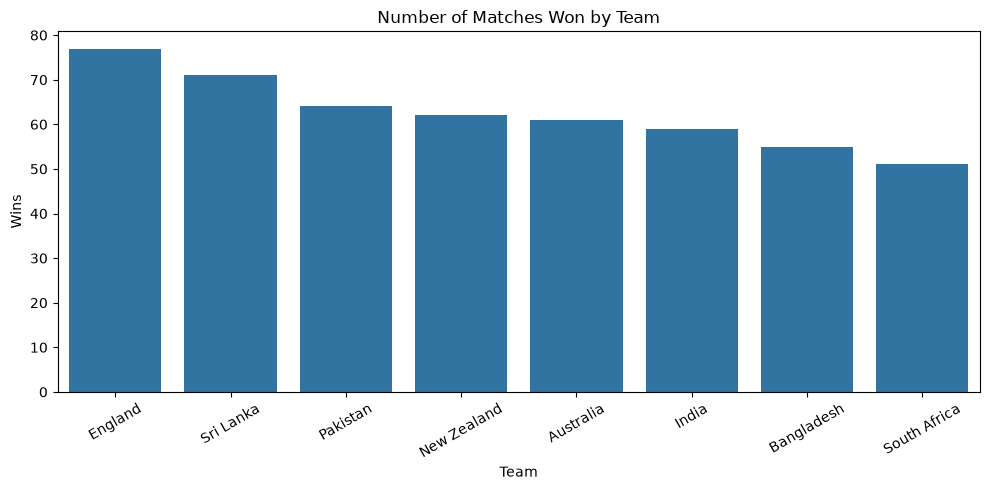

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="winner", order=df["winner"].value_counts().index)
plt.title("Number of Matches Won by Team")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


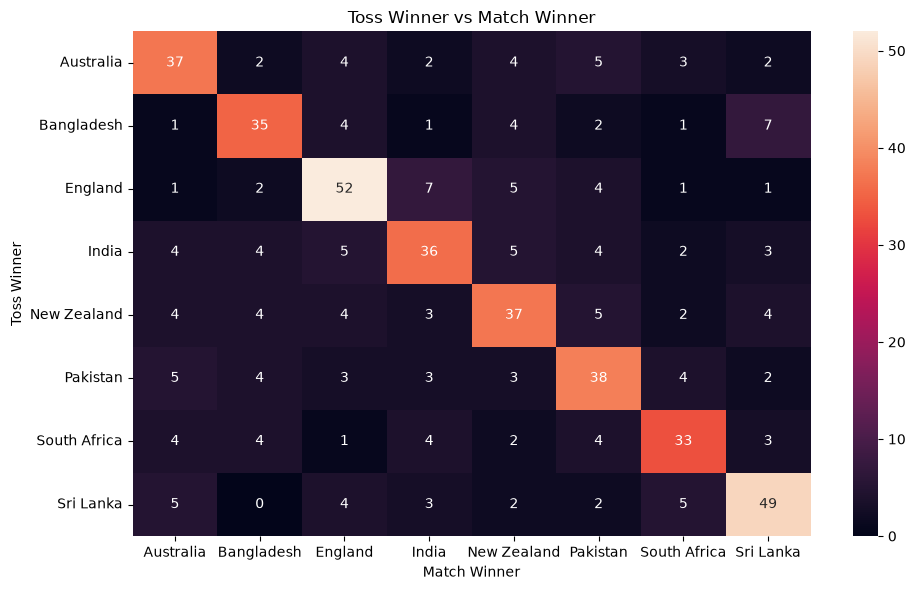

In [11]:
toss_table = pd.crosstab(df["toss_winner"], df["winner"])

plt.figure(figsize=(10,6))
sns.heatmap(toss_table, annot=True, fmt="d")
plt.title("Toss Winner vs Match Winner")
plt.xlabel("Match Winner")
plt.ylabel("Toss Winner")
plt.tight_layout()
plt.show()


In [12]:
features = [
    "team1", "team2", "venue", "toss_winner", "toss_decision",
    "team1_recent_wins", "team2_recent_wins",
    "team1_rating", "team2_rating",
    "team1_avg_score", "team2_avg_score"
]

X = df[features]
y = df["winner"]

print("Input features:")
display(X.head())

print("Target:")
display(y.head())


Input features:


,team1,team2,venue,toss_winner,toss_decision,team1_recent_wins,team2_recent_wins,team1_rating,team2_rating,team1_avg_score,team2_avg_score
0,Australia,Pakistan,Hyderabad,Pakistan,Bat,9,5,80,93,202,185
1,Bangladesh,England,Kolkata,England,Field,7,6,94,86,176,208
2,India,Bangladesh,Ahmedabad,India,Field,5,6,92,89,206,152
3,South Africa,England,Chennai,South Africa,Field,7,4,89,97,196,209
4,Pakistan,Bangladesh,Chennai,Bangladesh,Field,4,8,75,91,191,153


Target:


0       Australia
1         England
2           India
3    South Africa
4      Bangladesh
Name: winner, dtype: str

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 400
Testing rows: 100


In [14]:
categorical_features = [
    "team1", "team2", "venue", "toss_winner", "toss_decision"
]

numeric_features = [
    "team1_recent_wins", "team2_recent_wins",
    "team1_rating", "team2_rating",
    "team1_avg_score", "team2_avg_score"
]

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", StandardScaler(), numeric_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


In [15]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.2%}")


Logistic Regression Accuracy: 60.00%


In [16]:
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=8, random_state=42))
])

decision_tree_model.fit(X_train, y_train)
decision_tree_pred = decision_tree_model.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

print(f"Decision Tree Accuracy: {decision_tree_accuracy:.2%}")


Decision Tree Accuracy: 61.00%


In [17]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

random_forest_model.fit(X_train, y_train)
random_forest_pred = random_forest_model.predict(X_test)
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)

print(f"Random Forest Accuracy: {random_forest_accuracy:.2%}")


Random Forest Accuracy: 67.00%


,Model,Accuracy (%)
0,Logistic Regression,60.0
1,Decision Tree,61.0
2,Random Forest,67.0


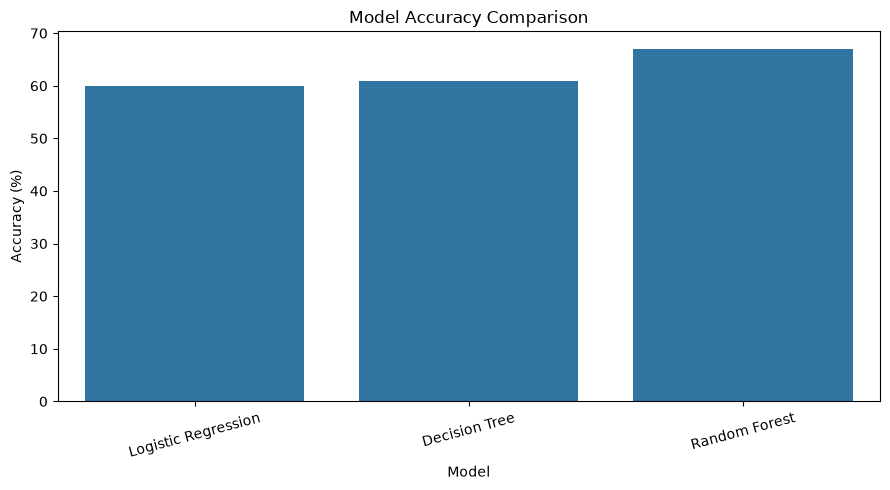

In [18]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy (%)": [
        logistic_accuracy * 100,
        decision_tree_accuracy * 100,
        random_forest_accuracy * 100
    ]
})

display(comparison)

plt.figure(figsize=(9,5))
sns.barplot(data=comparison, x="Model", y="Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [19]:
print("Random Forest Classification Report")
print(classification_report(
    y_test,
    random_forest_pred,
    zero_division=0
))


Random Forest Classification Report
              precision    recall  f1-score   support

   Australia       0.57      0.67      0.62        12
  Bangladesh       0.70      0.64      0.67        11
     England       0.67      0.62      0.65        16
       India       0.67      0.67      0.67        12
 New Zealand       0.62      0.83      0.71        12
    Pakistan       0.69      0.69      0.69        13
South Africa       0.75      0.60      0.67        10
   Sri Lanka       0.75      0.64      0.69        14

    accuracy                           0.67       100
   macro avg       0.68      0.67      0.67       100
weighted avg       0.68      0.67      0.67       100



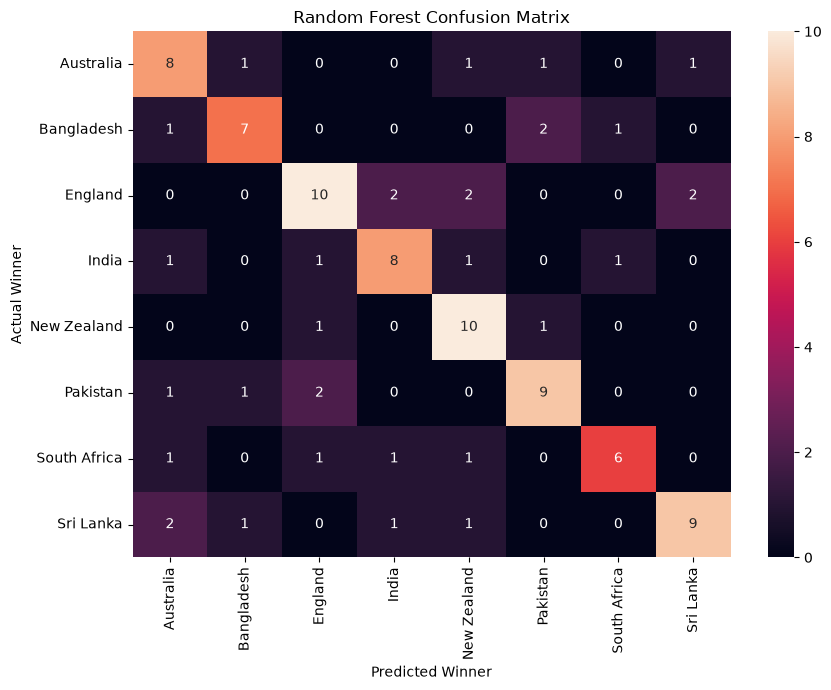

In [20]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, random_forest_pred, labels=labels)

plt.figure(figsize=(9,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Winner")
plt.ylabel("Actual Winner")
plt.tight_layout()
plt.show()


In [21]:
new_match = pd.DataFrame([{
    "team1": "India",
    "team2": "Australia",
    "venue": "Mumbai",
    "toss_winner": "India",
    "toss_decision": "Bat",
    "team1_recent_wins": 8,
    "team2_recent_wins": 7,
    "team1_rating": 92,
    "team2_rating": 89,
    "team1_avg_score": 188,
    "team2_avg_score": 181
}])

prediction = random_forest_model.predict(new_match)[0]

print("================================")
print("AI CRICKET MATCH PREDICTION")
print("================================")
print("Predicted Winner:", prediction)


AI CRICKET MATCH PREDICTION
Predicted Winner: India


In [22]:
probabilities = random_forest_model.predict_proba(new_match)[0]
classes = random_forest_model.named_steps["classifier"].classes_

for team, probability in zip(classes, probabilities):
    print(f"{team}: {probability:.2%}")


Australia: 8.00%
Bangladesh: 5.50%
England: 3.50%
India: 48.50%
New Zealand: 3.50%
Pakistan: 17.00%
South Africa: 1.50%
Sri Lanka: 12.50%


In [23]:
joblib.dump(random_forest_model, "cricket_winner_model.pkl")
print("Model saved as cricket_winner_model.pkl")


Model saved as cricket_winner_model.pkl


In [24]:
loaded_model = joblib.load("cricket_winner_model.pkl")
loaded_prediction = loaded_model.predict(new_match)[0]
print("Prediction from saved model:", loaded_prediction)


Prediction from saved model: India


In [27]:
# Enter values that are compatible with the dataset.
team1 = input("Team 1: ")
team2 = input("Team 2: ")
venue = input("Venue: ")
toss_winner = input("Toss winner: ")
toss_decision = input("Toss decision (Bat/Field): ")

team1_recent_wins = int(input("Team 1 recent wins: "))
team2_recent_wins = int(input("Team 2 recent wins: "))
team1_rating = int(input("Team 1 rating: "))
team2_rating = int(input("Team 2 rating: "))
team1_avg_score = int(input("Team 1 average score: "))
team2_avg_score = int(input("Team 2 average score: "))

user_match = pd.DataFrame([{
    "team1": team1,
    "team2": team2,
    "venue": venue,
    "toss_winner": toss_winner,
    "toss_decision": toss_decision,
    "team1_recent_wins": team1_recent_wins,
    "team2_recent_wins": team2_recent_wins,
    "team1_rating": team1_rating,
    "team2_rating": team2_rating,
    "team1_avg_score": team1_avg_score,
    "team2_avg_score": team2_avg_score
}])

user_prediction = loaded_model.predict(user_match)[0]
print("\nPredicted Winner:", user_prediction)



Predicted Winner: Australia
